# ML PROJECT 3
# CLASSIFICATION DATASET: AIRLINE PASSENGER SATISFACTION DATASET

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
--- DATA LOAD ---

In [2]:
df=pd.read_csv("C:/Users/YUKESH/Downloads/Airline_Passenger_Satisfaction_Dataset.csv")
df

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,Male,disloyal Customer,34,Business travel,Business,526,3,3,3,1,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
25972,Male,Loyal Customer,23,Business travel,Business,646,4,4,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
25973,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,1,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
25974,Male,Loyal Customer,14,Business travel,Business,1127,3,3,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


In [ ]:
--- ENCODING ---

In [3]:
encode=LabelEncoder()
df["Gender"]=encode.fit_transform(df["Gender"])
df["Customer Type"]=encode.fit_transform(df["Customer Type"])
df["Type of Travel"]=encode.fit_transform(df["Type of Travel"])
df["satisfaction"]=encode.fit_transform(df["satisfaction"])

In [ ]:
--- MAPPING ---

In [4]:
df["Class"].unique()

array(['Eco', 'Business', 'Eco Plus'], dtype=object)

In [5]:
df["Class"] = df["Class"].map({"Eco":0,"Business":1,"Eco Plus":2})

In [6]:
df

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,0,52,0,0,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,1
1,0,0,36,0,1,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,1
2,1,1,20,0,0,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,0
3,1,0,44,0,1,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,1
4,0,0,49,0,0,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,1,1,34,0,1,526,3,3,3,1,...,4,3,2,4,4,5,4,0,0.0,0
25972,1,0,23,0,1,646,4,4,4,4,...,4,4,5,5,5,5,4,0,0.0,1
25973,0,0,17,1,0,828,2,5,1,5,...,2,4,3,4,5,4,2,0,0.0,0
25974,1,0,14,0,1,1127,3,3,3,3,...,4,3,2,5,4,5,4,0,0.0,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             25976 non-null  int64  
 1   Customer Type                      25976 non-null  int64  
 2   Age                                25976 non-null  int64  
 3   Type of Travel                     25976 non-null  int64  
 4   Class                              25976 non-null  int64  
 5   Flight Distance                    25976 non-null  int64  
 6   Inflight wifi service              25976 non-null  int64  
 7   Departure/Arrival time convenient  25976 non-null  int64  
 8   Ease of Online booking             25976 non-null  int64  
 9   Gate location                      25976 non-null  int64  
 10  Food and drink                     25976 non-null  int64  
 11  Online boarding                    25976 non-null  int

In [8]:
df.describe()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
count,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,...,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.00000,25893.000000,25976.000000
mean,0.492917,0.184747,39.620958,0.305590,0.628619,1193.788459,2.724746,3.046812,2.756775,2.977094,...,3.357753,3.385664,3.350169,3.633238,3.314175,3.649253,3.286226,14.30609,14.740857,0.438982
std,0.499959,0.388100,15.135685,0.460666,0.617308,998.683999,1.335384,1.533371,1.412951,1.282133,...,1.338299,1.282088,1.318862,1.176525,1.269332,1.180681,1.319330,37.42316,37.517539,0.496272
min,0.000000,0.000000,7.000000,0.000000,0.000000,31.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,27.000000,0.000000,0.000000,414.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.00000,0.000000,0.000000
50%,0.000000,0.000000,40.000000,0.000000,1.000000,849.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000,0.000000
75%,1.000000,0.000000,51.000000,1.000000,1.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.00000,13.000000,1.000000
max,1.000000,1.000000,85.000000,1.000000,2.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1128.00000,1115.000000,1.000000


In [ ]:
--- HANDLING NULL VALUES ---

In [9]:
df.isnull().sum()

Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0
dtype: int64

In [10]:
df["Arrival Delay in Minutes"]=df["Arrival Delay in Minutes"].fillna(df.groupby("satisfaction")["Arrival Delay in Minutes"].transform("mean"))

In [11]:
df.isnull().sum()

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

In [ ]:
--- HANDLING OUTLIERS ---

In [12]:
def replace_outliers(dataframe,feature):
    q1=dataframe[feature].quantile(0.25)
    q3=dataframe[feature].quantile(0.75)
    iqr=q3-q1
    lower_range=q1-1.5*iqr
    upper_range=q3+1.5*iqr
    dataframe[feature]=np.where(dataframe[feature]<lower_range,lower_range,dataframe[feature])
    dataframe[feature]=np.where(dataframe[feature]>upper_range,upper_range,dataframe[feature])

<Axes: xlabel='Gender'>

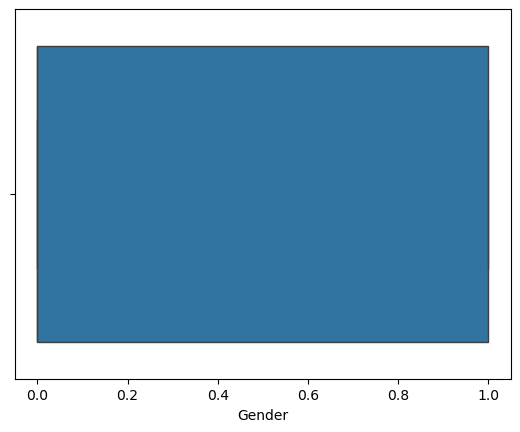

In [13]:
sns.boxplot(x="Gender",data=df)

<Axes: xlabel='Customer Type'>

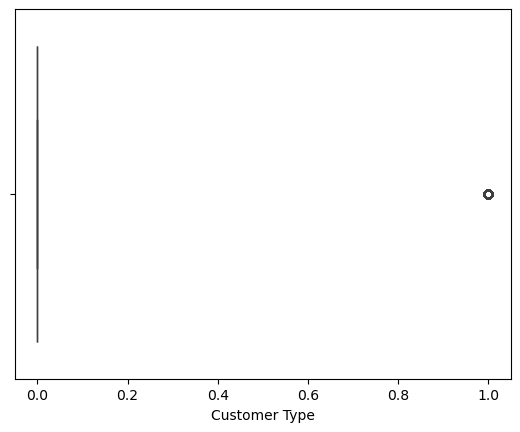

In [14]:
sns.boxplot(x="Customer Type",data=df)

<Axes: xlabel='Age'>

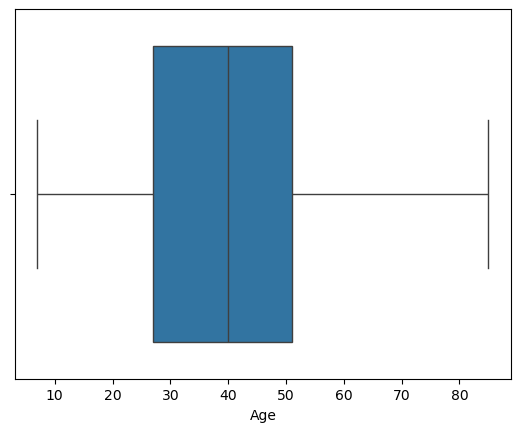

In [15]:
sns.boxplot(x="Age",data=df)

<Axes: xlabel='Type of Travel'>

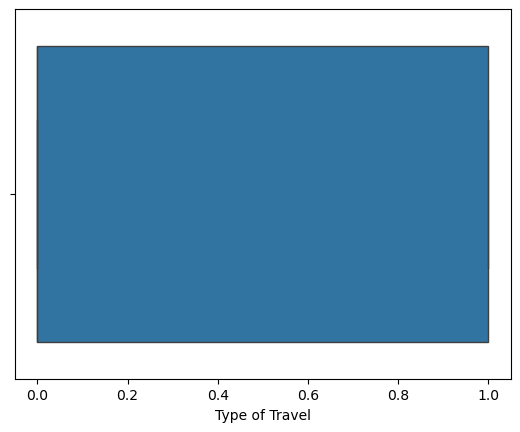

In [16]:
sns.boxplot(x="Type of Travel",data=df)

<Axes: xlabel='Class'>

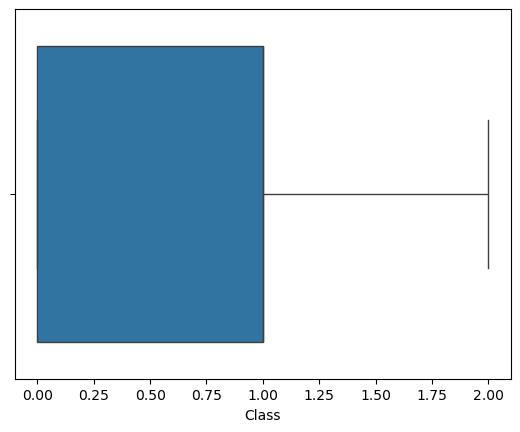

In [17]:
sns.boxplot(x="Class",data=df)

<Axes: xlabel='Flight Distance'>

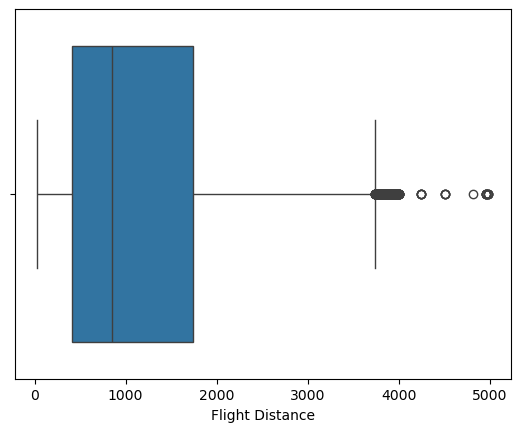

In [18]:
sns.boxplot(x="Flight Distance",data=df)

<Axes: xlabel='Flight Distance'>

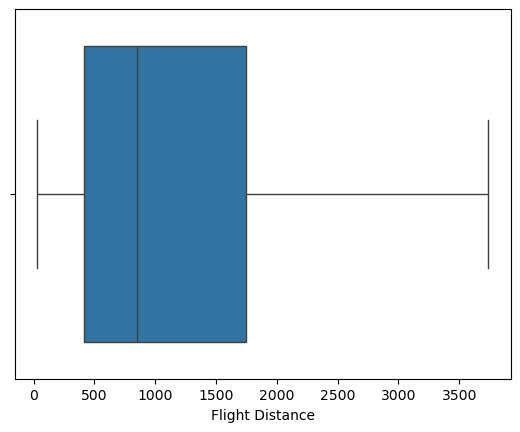

In [19]:
replace_outliers(df,'Flight Distance')
sns.boxplot(x='Flight Distance',data=df)

<Axes: xlabel='Inflight wifi service'>

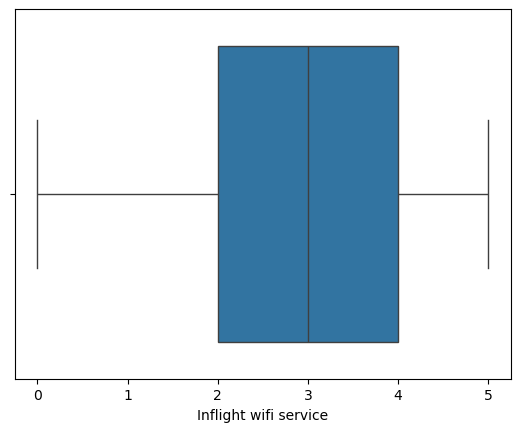

In [20]:
sns.boxplot(x="Inflight wifi service",data=df)

<Axes: xlabel='Departure/Arrival time convenient'>

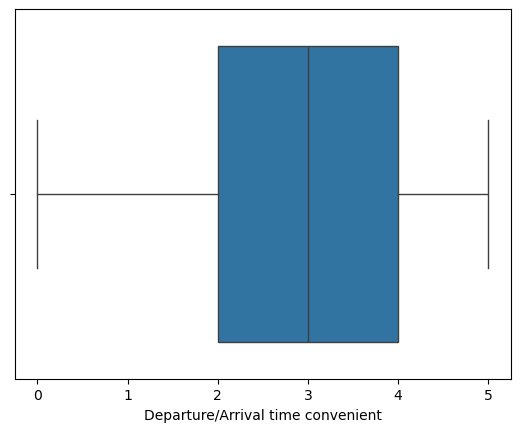

In [21]:
sns.boxplot(x="Departure/Arrival time convenient",data=df)

<Axes: xlabel='Ease of Online booking'>

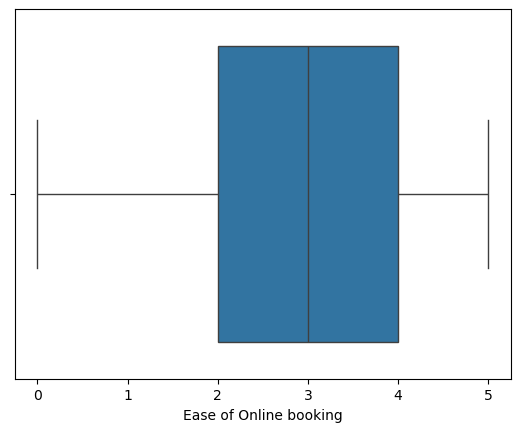

In [22]:
sns.boxplot(x="Ease of Online booking",data=df)

<Axes: xlabel='Gate location'>

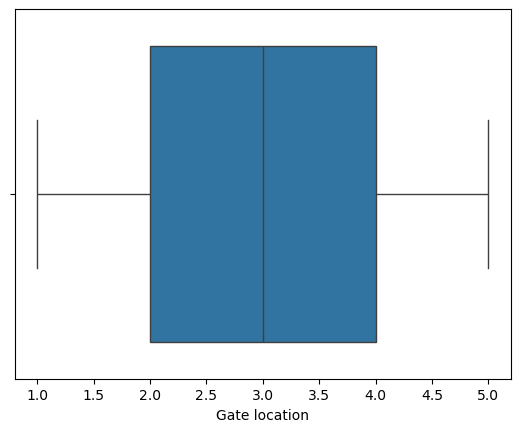

In [23]:
sns.boxplot(x="Gate location",data=df)

<Axes: xlabel='Food and drink'>

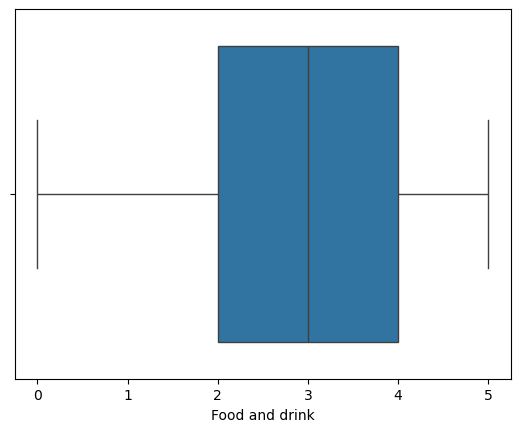

In [24]:
sns.boxplot(x="Food and drink",data=df)

<Axes: xlabel='Online boarding'>

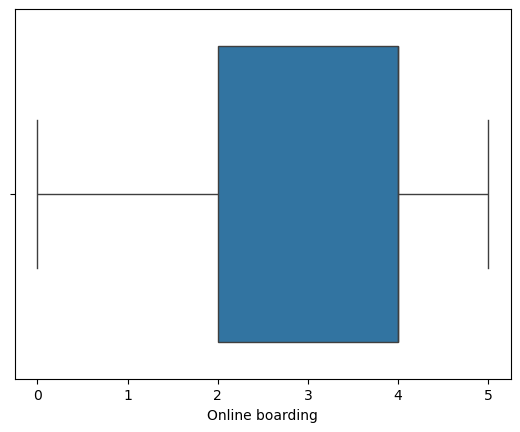

In [25]:
sns.boxplot(x="Online boarding",data=df)

<Axes: xlabel='Seat comfort'>

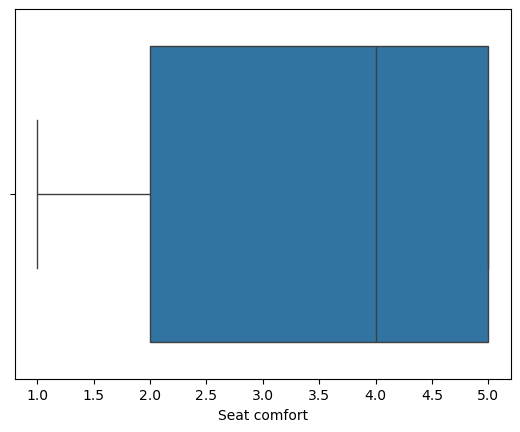

In [26]:
sns.boxplot(x="Seat comfort",data=df)

<Axes: xlabel='Inflight entertainment'>

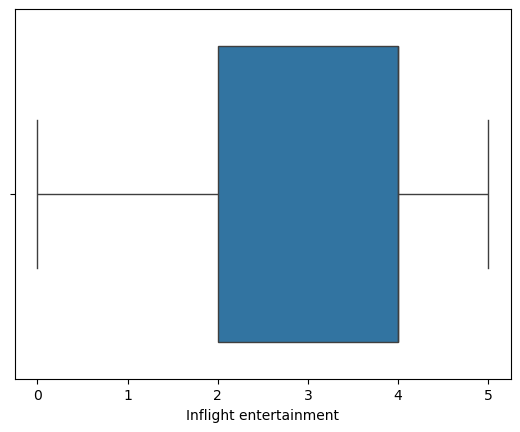

In [27]:
sns.boxplot(x="Inflight entertainment",data=df)

<Axes: xlabel='On-board service'>

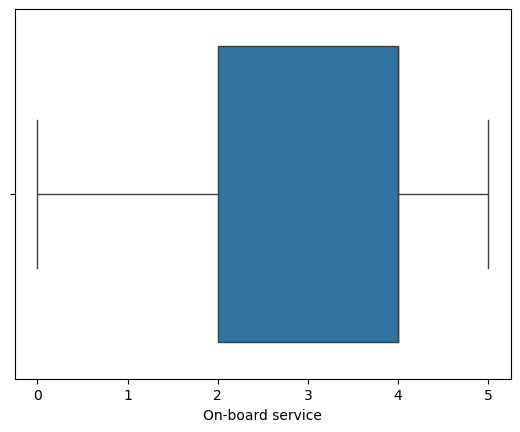

In [28]:
sns.boxplot(x="On-board service",data=df)

<Axes: xlabel='Leg room service'>

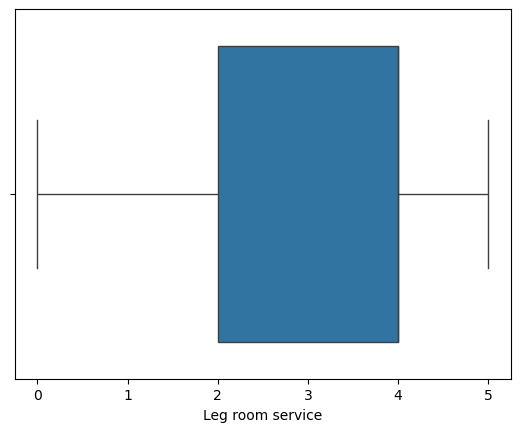

In [29]:
sns.boxplot(x="Leg room service",data=df)

<Axes: xlabel='Baggage handling'>

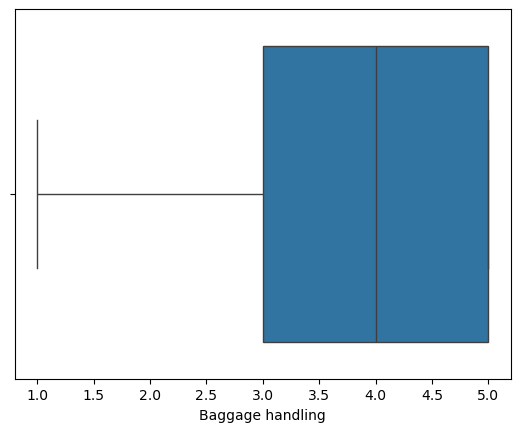

In [30]:
sns.boxplot(x="Baggage handling",data=df)

<Axes: xlabel='Checkin service'>

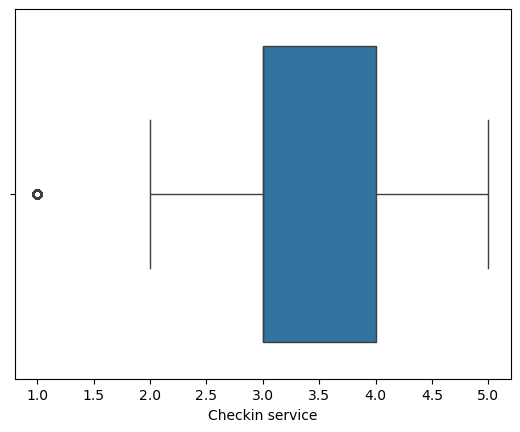

In [31]:
sns.boxplot(x="Checkin service",data=df)

<Axes: xlabel='Checkin service'>

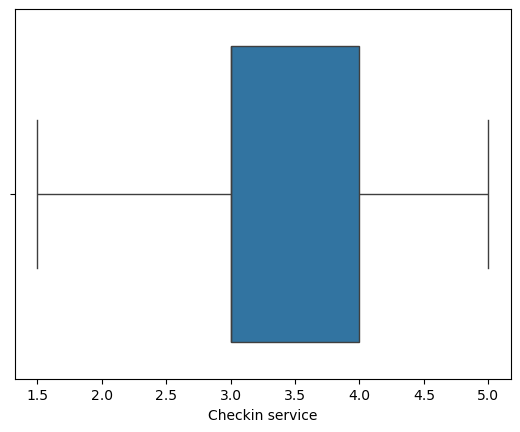

In [32]:
replace_outliers(df,'Checkin service')
sns.boxplot(x='Checkin service',data=df)

<Axes: xlabel='Inflight service'>

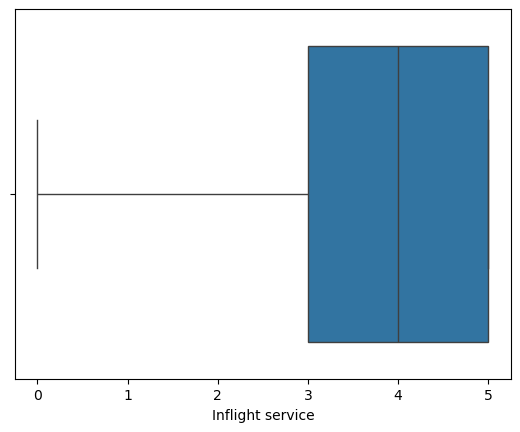

In [33]:
sns.boxplot(x="Inflight service",data=df)

<Axes: xlabel='Cleanliness'>

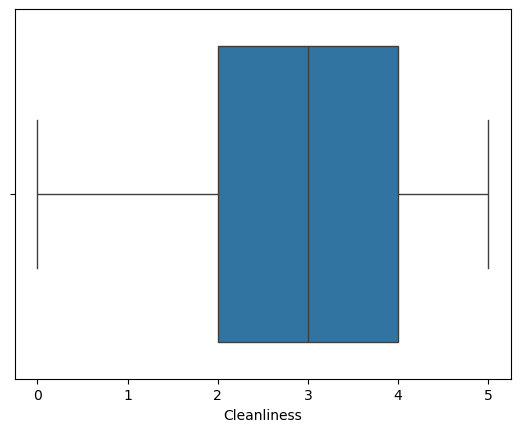

In [34]:
sns.boxplot(x="Cleanliness",data=df)

<Axes: xlabel='Departure Delay in Minutes'>

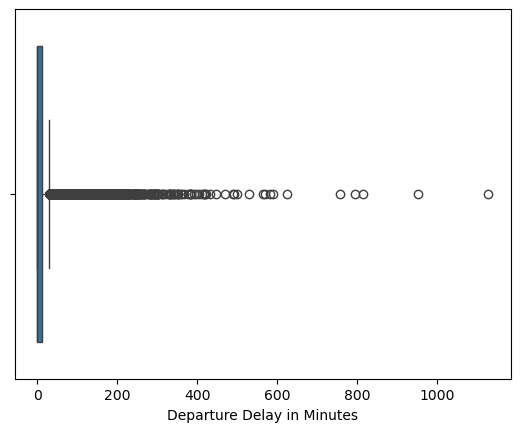

In [35]:
sns.boxplot(x="Departure Delay in Minutes",data=df)

<Axes: xlabel='Departure Delay in Minutes'>

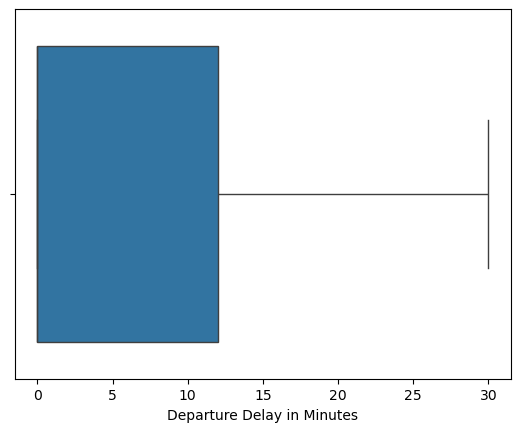

In [36]:
replace_outliers(df,'Departure Delay in Minutes')
sns.boxplot(x='Departure Delay in Minutes',data=df)

<Axes: xlabel='Arrival Delay in Minutes'>

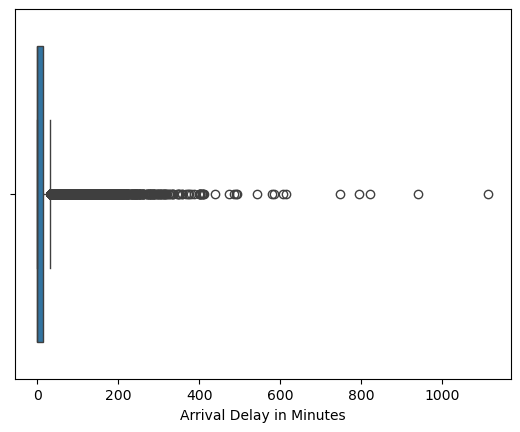

In [37]:
sns.boxplot(x="Arrival Delay in Minutes",data=df)

<Axes: xlabel='Arrival Delay in Minutes'>

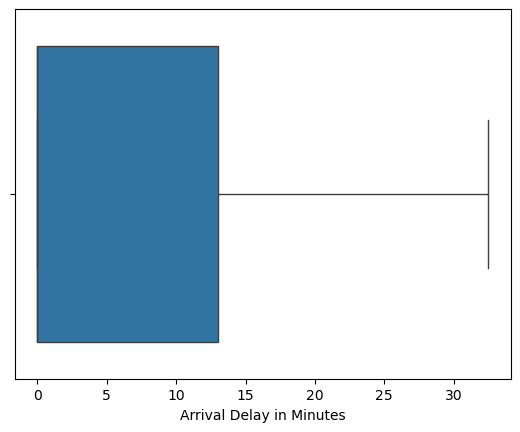

In [38]:
replace_outliers(df,'Arrival Delay in Minutes')
sns.boxplot(x='Arrival Delay in Minutes',data=df)

<Axes: xlabel='satisfaction'>

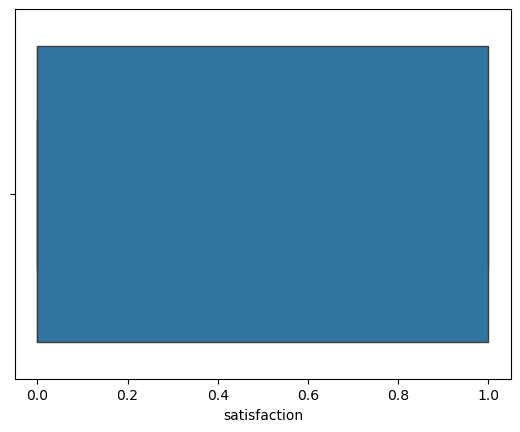

In [39]:
sns.boxplot(x="satisfaction",data=df)

In [ ]:
--- SPLITING Y AND X ---

In [40]:
y=df["satisfaction"]
y

0        1
1        1
2        0
3        1
4        1
        ..
25971    0
25972    1
25973    0
25974    1
25975    0
Name: satisfaction, Length: 25976, dtype: int64

In [41]:
x=df.drop("satisfaction",axis=1)
x

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,0,0,52,0,0,160.0,5,4,3,4,...,3,5,5,5,5,2.0,5,5,30.0,32.5
1,0,0,36,0,1,2863.0,1,1,3,1,...,5,4,4,4,4,3.0,4,5,0.0,0.0
2,1,1,20,0,0,192.0,2,0,2,4,...,2,2,4,1,3,2.0,2,2,0.0,0.0
3,1,0,44,0,1,3377.0,0,0,0,2,...,4,1,1,1,1,3.0,1,4,0.0,6.0
4,0,0,49,0,0,1182.0,2,3,4,3,...,2,2,2,2,2,4.0,2,4,0.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,1,1,34,0,1,526.0,3,3,3,1,...,4,4,3,2,4,4.0,5,4,0.0,0.0
25972,1,0,23,0,1,646.0,4,4,4,4,...,4,4,4,5,5,5.0,5,4,0.0,0.0
25973,0,0,17,1,0,828.0,2,5,1,5,...,2,2,4,3,4,5.0,4,2,0.0,0.0
25974,1,0,14,0,1,1127.0,3,3,3,3,...,4,4,3,2,5,4.0,5,4,0.0,0.0


In [ ]:
--- TRAINING PROCESS ---

In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
--- HADALING IMBALANCE DATA ---

In [43]:
y_train.value_counts()

satisfaction
0    11628
1     9152
Name: count, dtype: int64

In [44]:
smote = SMOTE(sampling_strategy='minority')
x_sm, y_sm = smote.fit_resample(x_train, y_train)
y_sm.value_counts()

satisfaction
1    11628
0    11628
Name: count, dtype: int64

In [ ]:
--- MODEL 1 ---
--- DECISION TREE CLASSIFIER ---

In [45]:
model1=DecisionTreeClassifier()
model1.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
# test_accurarcy
y_pred1=model1.predict(x_test)
accuracy1=accuracy_score(y_test,y_pred1)
accuracy1

0.9291762894534257

In [47]:
# training _accuracy 
y_train_pred1=model1.predict(x_train)
final_training1=accuracy_score(y_train_pred1,y_train)
final_training1

1.0

In [48]:
# Hyperparameter
model_1=DecisionTreeClassifier()
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2,5,6,7,3,10],
    'min_samples_leaf': [1, 2,3,4]
}

# GridSearchCV
grid_search = GridSearchCV(estimator=model_1, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Train
grid_search.fit(x_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

# Test accuracy
y_pred = best_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test,y_pred))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 10}
Accuracy: 0.9376443418013857


In [49]:
# The best parameter for decision tree 
model_1=DecisionTreeClassifier(max_depth= 10, min_samples_leaf= 3, min_samples_split= 10)

In [50]:
# test_accurarcy
model_1.fit(x_train,y_train)
y_pred_1=model_1.predict(x_test)
accuracy_1=accuracy_score(y_test,y_pred_1)
accuracy_1

0.9376443418013857

In [51]:
# training _accuracy 
y_train_pred_1=model_1.predict(x_train)
final_training_1=accuracy_score(y_train_pred_1,y_train)
final_training_1

0.9512512030798845

In [52]:
# classification_report
cr1 = classification_report(y_test, y_pred, target_names=["Satisfied as 0", "Neutral or Dissatisfied as 1"])
print("\nDecision tree:")
print("\nClassification Report:")
print(cr1)


Decision tree:

Classification Report:
                              precision    recall  f1-score   support

              Satisfied as 0       0.94      0.96      0.95      2945
Neutral or Dissatisfied as 1       0.94      0.91      0.93      2251

                    accuracy                           0.94      5196
                   macro avg       0.94      0.93      0.94      5196
                weighted avg       0.94      0.94      0.94      5196



In [ ]:
--- MODEL 2 ---
--- RANDOM FOREST CLASSIFIER ---

In [53]:
model3=RandomForestClassifier()
model3.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
# test_accurarcy
y_pred3=model3.predict(x_test)
accuracy3=accuracy_score(y_test,y_pred3)
accuracy3

0.9505388760585065

In [55]:
# training _accuracy 
y_train_pred3=model3.predict(x_train)
final_training3=accuracy_score(y_train_pred3,y_train)
final_training3

0.9999518768046198

In [56]:
model_2=RandomForestClassifier()
parameter = {
    'n_estimators': [100,177],
    'max_features': [5,9],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2,5,6,7,3,10],
    'min_samples_leaf': [1, 2,3,4]
}

# RandomizedSearchCV
random = RandomizedSearchCV(estimator=model_2, param_distributions=parameter, cv=5, scoring='accuracy', n_jobs=-1)

# Train
random.fit(x_train, y_train)

# Best parameters
print("Best Parameters:", random.best_params_)

# Best model
best_model = random.best_estimator_

# Test accuracy
y_pred = best_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test,y_pred))

Best Parameters: {'n_estimators': 177, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 9, 'max_depth': 10}
Accuracy: 0.943225558121632


In [57]:
model_2=RandomForestClassifier(max_depth= 10,max_features= 9,min_samples_leaf= 2, min_samples_split= 6,n_estimators= 177)

In [58]:
model_2.fit(x_train,y_train)
y_pred_2=model_2.predict(x_test)
accuracy_2=accuracy_score(y_test,y_pred_2)
accuracy_2

0.9447652040030793

In [59]:
# training _accuracy 
y_train_pred_2=model_2.predict(x_train)
final_training_2=accuracy_score(y_train_pred_2,y_train)
final_training_2

0.9622714148219442

In [60]:
# classification_report
cr2 = classification_report(y_test, y_pred, target_names=["Satisfied as 0", "Neutral or Dissatisfied as 1"])
print("\nRandom Forest Classifier:")
print("\nClassification Report:")
print(cr2)


Random Forest Classifier:

Classification Report:
                              precision    recall  f1-score   support

              Satisfied as 0       0.95      0.95      0.95      2945
Neutral or Dissatisfied as 1       0.94      0.93      0.93      2251

                    accuracy                           0.94      5196
                   macro avg       0.94      0.94      0.94      5196
                weighted avg       0.94      0.94      0.94      5196



In [ ]:
--- SCALING ---

In [61]:
scale=StandardScaler()
x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.transform(x_test)

In [ ]:
--- MODEL 3 ---
--- LOGISTIC REGRESSION ---

In [62]:
model2=LogisticRegression()
model2.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [63]:
# test_accurarcy
y_pred2=model2.predict(x_test_scaled)
accuracy2=accuracy_score(y_test,y_pred2)
accuracy2

0.8625866050808314

In [64]:
# training _accuracy 
y_train_pred2=model2.predict(x_train_scaled)
final_training2=accuracy_score(y_train_pred2,y_train)
final_training2

0.8718479307025987

In [65]:
# classification_report
cr2 = classification_report(y_test, y_pred, target_names=["Satisfied as 0", "Neutral or Dissatisfied as 1"])
print("\nLogistic Regression:")
print("\nClassification Report:")
print(cr2)


Logistic Regression:

Classification Report:
                              precision    recall  f1-score   support

              Satisfied as 0       0.95      0.95      0.95      2945
Neutral or Dissatisfied as 1       0.94      0.93      0.93      2251

                    accuracy                           0.94      5196
                   macro avg       0.94      0.94      0.94      5196
                weighted avg       0.94      0.94      0.94      5196



In [ ]:
--- MODEL 4 ---
--- KNN [K NEAREST NEIGHBORS CLASSIFIER] ---

In [66]:
model4=KNeighborsClassifier()
model4.fit(x_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [67]:
# testing_accuracy
y_pred4=model4.predict(x_test_scaled)
accuracy4=accuracy_score(y_test,y_pred4)
accuracy4

0.9151270207852193

In [68]:
# training _accuracy 
y_train_pred4=model4.predict(x_train_scaled)
final_training4=accuracy_score(y_train_pred4,y_train)
final_training4

0.939990375360924

In [69]:
# hyper parameter
model_3=KNeighborsClassifier()

parameter = {'n_neighbors': [3,5,7], 'metric': ['euclidean', 'manhattan'] }

random = RandomizedSearchCV( estimator=model_3, param_distributions=parameter, cv=5, scoring='accuracy' )

random.fit(x_train_scaled,y_train)

print("Best parameters:", random.best_params_)

print("Best CV score:", random.best_score_)

C:\Users\YUKESH\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'n_neighbors': 7, 'metric': 'manhattan'}
Best CV score: 0.9265158806544755


In [70]:
# Applying best parameter
model_3=KNeighborsClassifier(metric='manhattan',n_neighbors=5)

In [71]:
# testing_accuracy (after applying best parameter)
model_3.fit(x_train_scaled,y_train)
y_pred_3=model_3.predict(x_test_scaled)
accuracy_3=accuracy_score(y_test,y_pred_3)
accuracy_3

0.9232101616628176

In [72]:
# training _accuracy 
y_train_pred_3=model_3.predict(x_train_scaled)
final_training_3=accuracy_score(y_train,y_train_pred_3)
final_training_3

0.9479307025986525

In [73]:
# clssification_report
cr4 = classification_report(y_test, y_pred, target_names=["Satisfied as 0", "Neutral or Dissatisfied as 1"])
print("\nK Nearest Neighbors:")
print("\nClassification Report:")
print(cr4)


K Nearest Neighbors:

Classification Report:
                              precision    recall  f1-score   support

              Satisfied as 0       0.95      0.95      0.95      2945
Neutral or Dissatisfied as 1       0.94      0.93      0.93      2251

                    accuracy                           0.94      5196
                   macro avg       0.94      0.94      0.94      5196
                weighted avg       0.94      0.94      0.94      5196



In [ ]:
--- MODEL 5 ---
--- NAIVE BAYES ---

In [74]:
model5=GaussianNB()
model5.fit(x_train_scaled,y_train)

,priors,None
,var_smoothing,1e-09


In [75]:
# testing_accuracy
y_pred5=model5.predict(x_test_scaled)
accuracy5=accuracy_score(y_test,y_pred5)
accuracy5

0.8618167821401078

In [76]:
# training _accuracy 
y_train_pred5=model5.predict(x_train_scaled)
final_training5=accuracy_score(y_train,y_train_pred5)
final_training5

0.8687680461982675

In [77]:
# classification_report
cr5 = classification_report(y_test, y_pred, target_names=["Satisfied as 0", "Neutral or Dissatisfied as 1"])
print("\nNaive bayes")
print("\nClassification Report:")
print(cr5)


Naive bayes

Classification Report:
                              precision    recall  f1-score   support

              Satisfied as 0       0.95      0.95      0.95      2945
Neutral or Dissatisfied as 1       0.94      0.93      0.93      2251

                    accuracy                           0.94      5196
                   macro avg       0.94      0.94      0.94      5196
                weighted avg       0.94      0.94      0.94      5196



In [ ]:
--- MODEL 6 ---
--- SVM [SUPPORT VECTOR MACHINE CLASSIFIER] ---

In [78]:
model6=SVC()
model6.fit(x_train_scaled,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [79]:
# testing_accuracy
y_pred6=model6.predict(x_test_scaled)
accuracy6=accuracy_score(y_test,y_pred6)
accuracy6

0.939183987682833

In [80]:
# training _accuracy 
y_train_pred6=model6.predict(x_train_scaled)
final_training6=accuracy_score(y_train_pred6,y_train)
final_training6

0.9556785370548604

In [81]:
# Define the model
model_4 = SVC()

# Define parameter grid
parameter = {'C': [0.1, 1, 7,0.4], 'kernel': ['linear', 'rbf'] }

# Grid Search
ran = RandomizedSearchCV( estimator=model_4, param_distributions=parameter, cv=5, scoring='accuracy' )

# Fit using your own training data
ran.fit(x_train_scaled, y_train)

# Best parameters
print("Best parameters:", ran.best_params_)

# Best CV score
print("Best CV score:", ran.best_score_)

C:\Users\YUKESH\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'kernel': 'rbf', 'C': 7}
Best CV score: 0.9462945139557266


In [82]:
model_4=SVC(kernel='rbf', C= 7)
model_4.fit(x_train_scaled,y_train)
y_pred_4=model_4.predict(x_test_scaled)
accuracy_4=accuracy_score(y_test,y_pred_4)
accuracy_4

0.9464973056197075

In [83]:
# training _accuracy 
y_train_pred_4=model_4.predict(x_train_scaled)
final_training_4=accuracy_score(y_train,y_train_pred_4)
final_training_4

0.9768527430221366

In [84]:
# classification_report
cr6 = classification_report(y_test, y_pred, target_names=["Satisfied as 0", "Neutral or Dissatisfied as 1"])
print("\nSupport vector machine:")
print("\nClassification Report:")
print(cr6)


Support vector machine:

Classification Report:
                              precision    recall  f1-score   support

              Satisfied as 0       0.95      0.95      0.95      2945
Neutral or Dissatisfied as 1       0.94      0.93      0.93      2251

                    accuracy                           0.94      5196
                   macro avg       0.94      0.94      0.94      5196
                weighted avg       0.94      0.94      0.94      5196

